In [1]:
import pandas as pd
import numpy as np
import joblib
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns

In [2]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, norm
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from umap import UMAP

In [89]:
import xgboost as xgb

In [4]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [5]:
from helper.plots import feature_plots
from helper.utils import data_tools

### 4. Детальное изучение признаков

**Загрузим данные.**

In [6]:
url = "./data/creditcard.csv"
data = pd.read_csv(url)

EDA показал, что `Time` и `Amount` **находятся на другом масштабе** по сравнению с признаками `V1`–`V28`. **Разные масштабы могут негативно влиять на работу моделей, особенно линейных**. Поэтому мы выполнем масштабирование этих признаков и удалим их исходные версии, чтобы использовать только нормализованные данные.

Посмотрим метрики модели перед любыми изменениями.

Classifier | Accuracy: 0.98 | Recall: 0.92 | Presicion: 0.06 | F1_score: 0.12 | Roc-Auc: 0.98


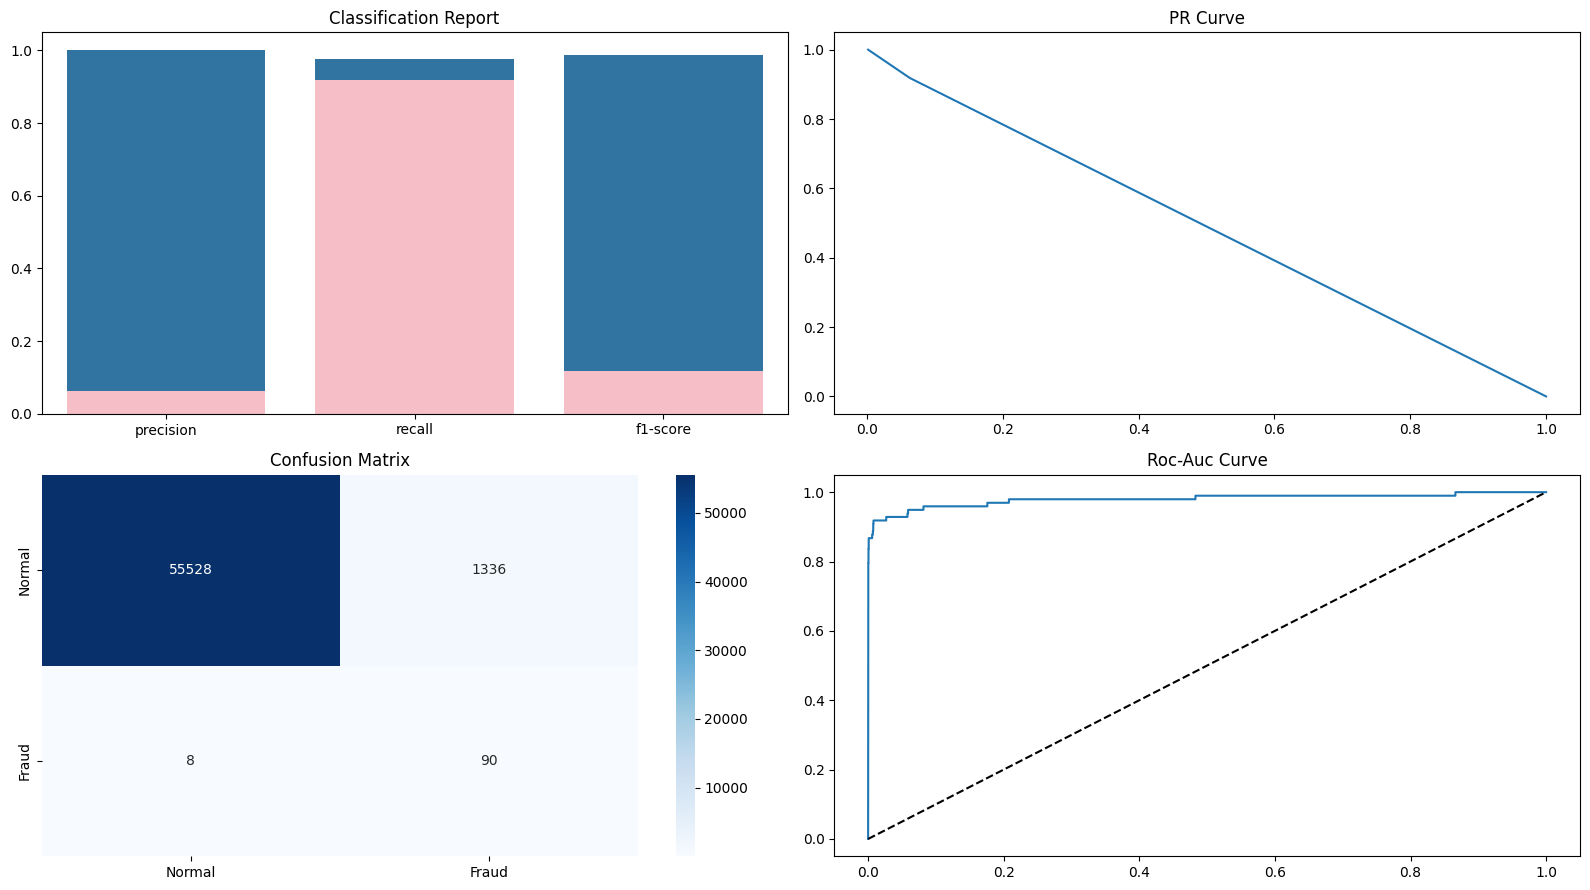

In [7]:
baseline_model, baseline_metrics, label = data_tools.PipelineManager(data, 'Class', LogisticRegression(class_weight='balanced', max_iter=1000)).get_baseline()

#### 4.1. Логарифмирование и стандартизация

**Большие суммы - обрезать их вслепую нельзя**, иначе можно уничтожить самую информативную часть данных. То есть это не шум — это информация, поэтому **применим логарифмическое преобразование**, а после **применим масштабирование**.

Преимущества:

* уменьшает влияние экстремальных значений

* сохраняет информацию о больших суммах

* улучшает линейные модели

* ускоряет обучение

In [8]:
data['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
data['Amount'] = np.log1p(data['Amount'])

In [11]:
scaler = StandardScaler()

data['scaled_time'] = scaler.fit_transform(data[['Time']])
data['scaled_amount'] = scaler.fit_transform(data[['Amount']])

data = data.drop(columns=['Time', 'Amount'])

In [12]:
data['scaled_amount'].describe()

count    2.848070e+05
mean     9.101110e-17
std      1.000002e+00
min     -1.902754e+00
25%     -7.636627e-01
50%     -1.007690e-02
75%      7.283598e-01
max      4.226464e+00
Name: scaled_amount, dtype: float64

Посмотрим **распределение классов по сумме транзакций**.

In [16]:
neg_class = data.loc[data['Class'] == 0]
pos_class = data.loc[data['Class'] == 1]

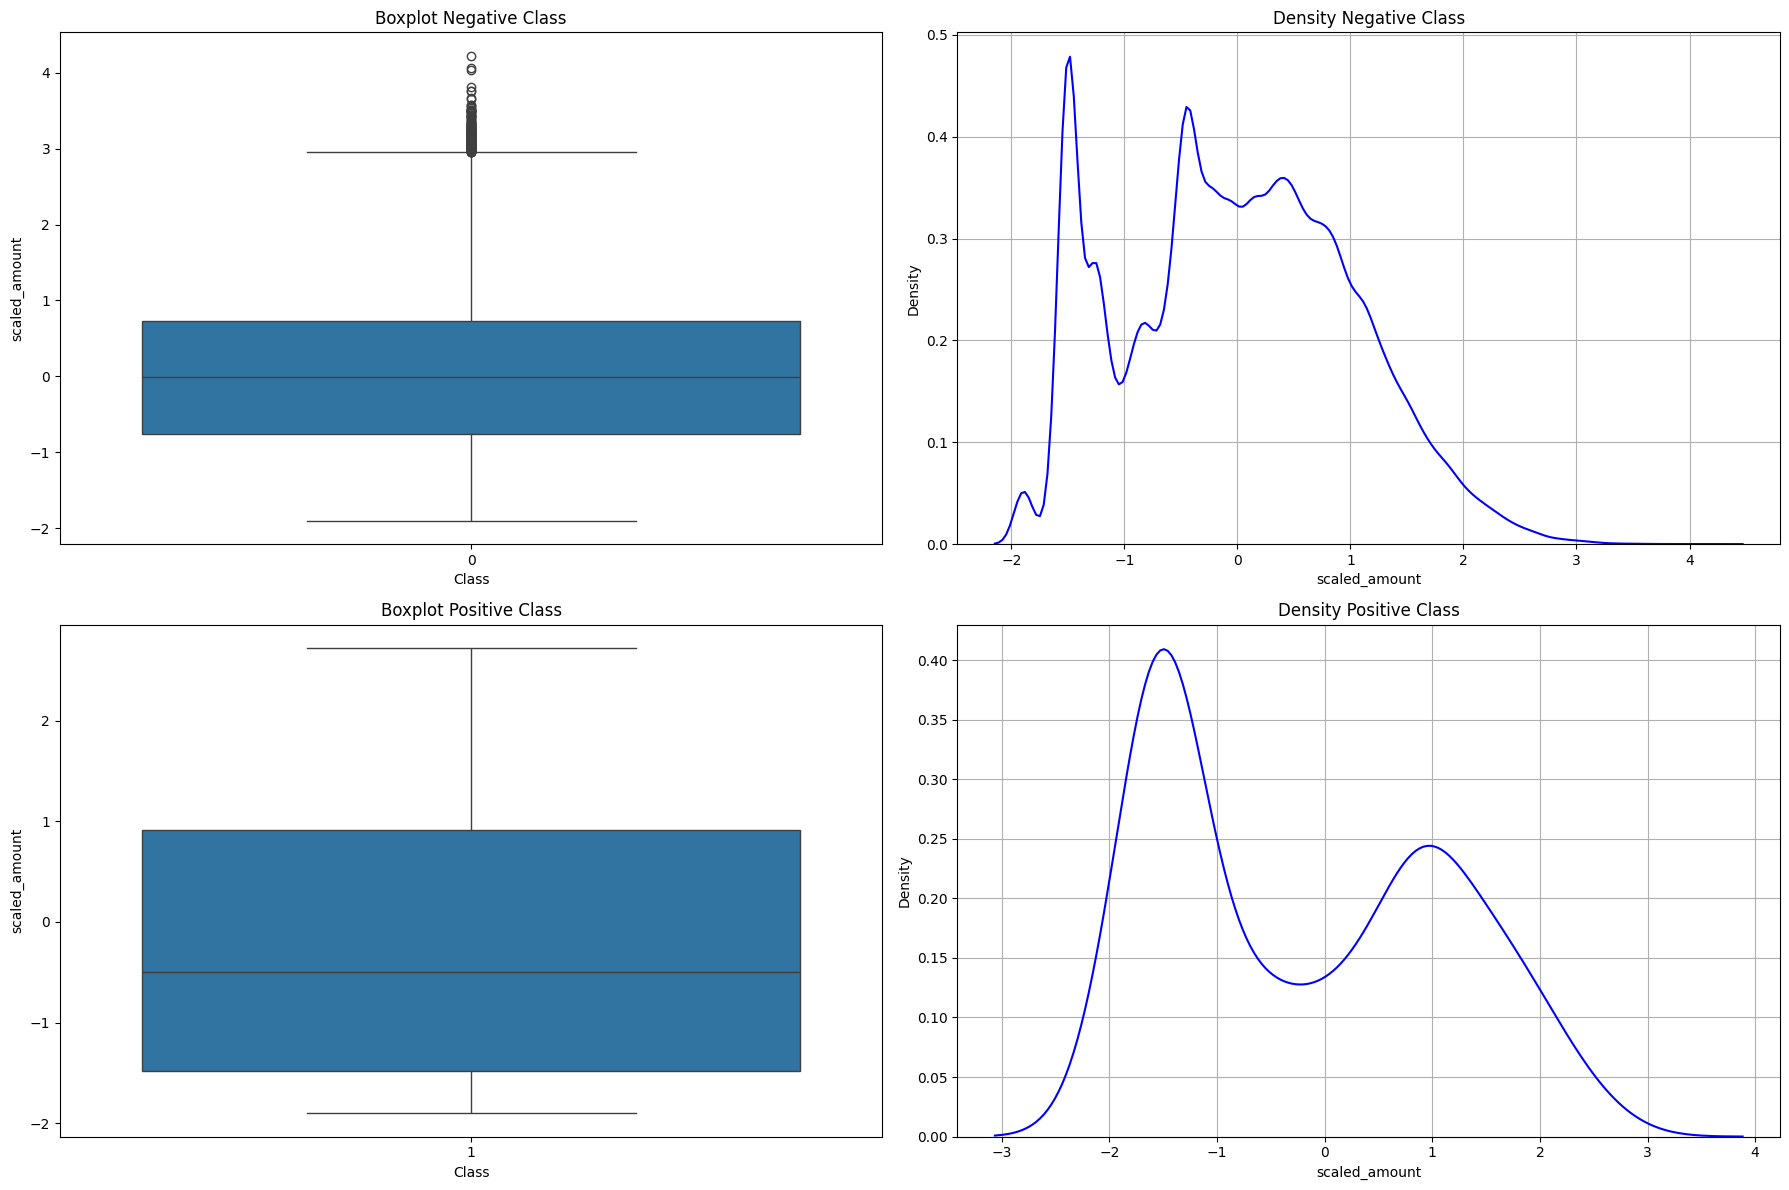

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(x="Class", y='scaled_amount', data=neg_class, ax=ax[0][0])
ax[0][0].set_title('Boxplot Negative Class')

sns.boxplot(x="Class", y='scaled_amount', data=pos_class, ax=ax[1][0])
ax[1][0].set_title('Boxplot Positive Class')

sns.kdeplot(neg_class['scaled_amount'], ax=ax[0][1], color='b')
ax[0][1].set_title('Density Negative Class')
ax[0][1].grid(True)
sns.kdeplot(pos_class['scaled_amount'], ax=ax[1][1], color='b')
ax[1][1].set_title('Density Positive Class')
ax[1][1].grid(True)

plt.tight_layout()
plt.show()

**Boxplot — Negative Class (Class = 0)** У нормальных транзакций распределение scaled_amount относительно компактное: медиана вокруг нуля, большинство значений лежат примерно между −1.5 и +1. Тем не менее присутствует значительное количество выбросов сверху — точки, уходящие выше 3–4 стандартных отклонений. Это означает, что среди корректных транзакций встречаются редкие, но большие суммы. После стандартизации такие транзакции выглядят как выбросы, но в реальности могут быть вполне нормальными (например, крупные покупки).

**Boxplot — Positive Class (Class = 1)** Для мошеннических транзакций распределение выглядит более широким и равномерным, чем для класса 0. Медиана смещена в отрицательную область → значит многие fraudulent-суммы меньше среднего значения нормальных транзакций. Верхняя часть боксплота (до ~2.5–2.7) показывает, что среди фрода есть и транзакции с относительно большими суммами. Выбросов значительно меньше, чем у класса 0 — это говорит о более сдержанном диапазоне сумм.

**Density Plot — Negative Class (Class = 0)** Распределение мультимодальное (несколько пиков): примерно в областях −2...−1 и около 0...0.5. Это означает, что нормальные транзакции можно условно разделить на несколько групп по сумме. Практически вся плотность сосредоточена в диапазоне −2.5 до +2 → это ожидаемо, так как стандартное масштабирование центрирует данные. "Хвост" вправо довольно длинный → есть редкие крупные транзакции.

**Density Plot — Positive Class (Class = 1)** Распределение также мультимодальное, но пики расположены иначе:
один крупный пик около −1.8, другой — около +1.

Это говорит о двух разных типах мошеннических транзакций:
- очень небольшие суммы (вероятно, частое мошенничество),
- более крупные суммы (иногда мошенники пытаются "ударить по-крупному").

Оценим выбросы сумм транзакций по изоляционному лесу.

In [14]:
features = [col for col in data.columns if col not in ['Class']]

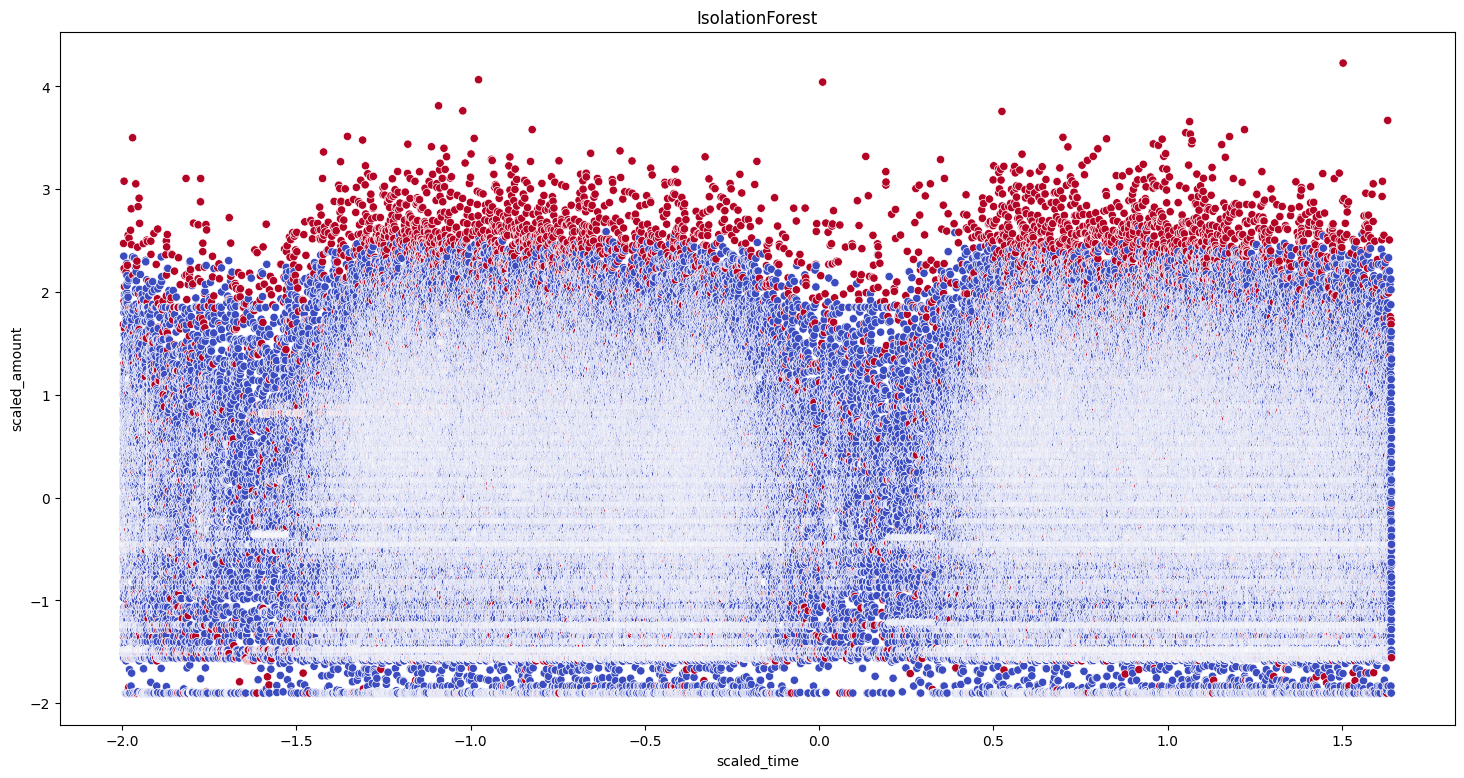

In [21]:
isoforest = IsolationForest(contamination=0.05, random_state=42)
predict = isoforest.fit_predict(neg_class[features])
predict = pd.Series(predict).map({1: 0, -1: 1})

plt.figure(figsize=(18, 9))
sns.scatterplot(x=neg_class['scaled_time'], y=neg_class['scaled_amount'], c=predict, cmap='coolwarm');
plt.title('IsolationForest')
plt.show()

Т.к. выявление аномалий в мошеннических операций не имеет смысла, потому что это и есть аномалия, то проверили результат boxplot по обычным операциям через изоляционный лес. С его помощью видно, что превышение масштабированного `Amount` более 2.5 маркируется как аномалия, что так же подтверждается boxplot.

#### 4.2. Оценка разделимости классов

Для оценки разделимости классов **сформируем тестовый набор** с равным количеством положительных (Fraud) и отрицательных (Normal) примеров. Это **позволит визуально проверить, насколько хорошо классы разделяются** после применения методов снижения размерности.

In [23]:
positive_class = data[data['Class'] == 1]
negative_class = data[data['Class'] == 0].sample(n=len(positive_class), random_state=42)

weighted_data = (pd.concat([positive_class, negative_class]).sample(frac=1, random_state=42).reset_index(drop=True))

In [25]:
X_weighted = weighted_data.drop(columns=['Class'])
y_weighted = weighted_data['Class']

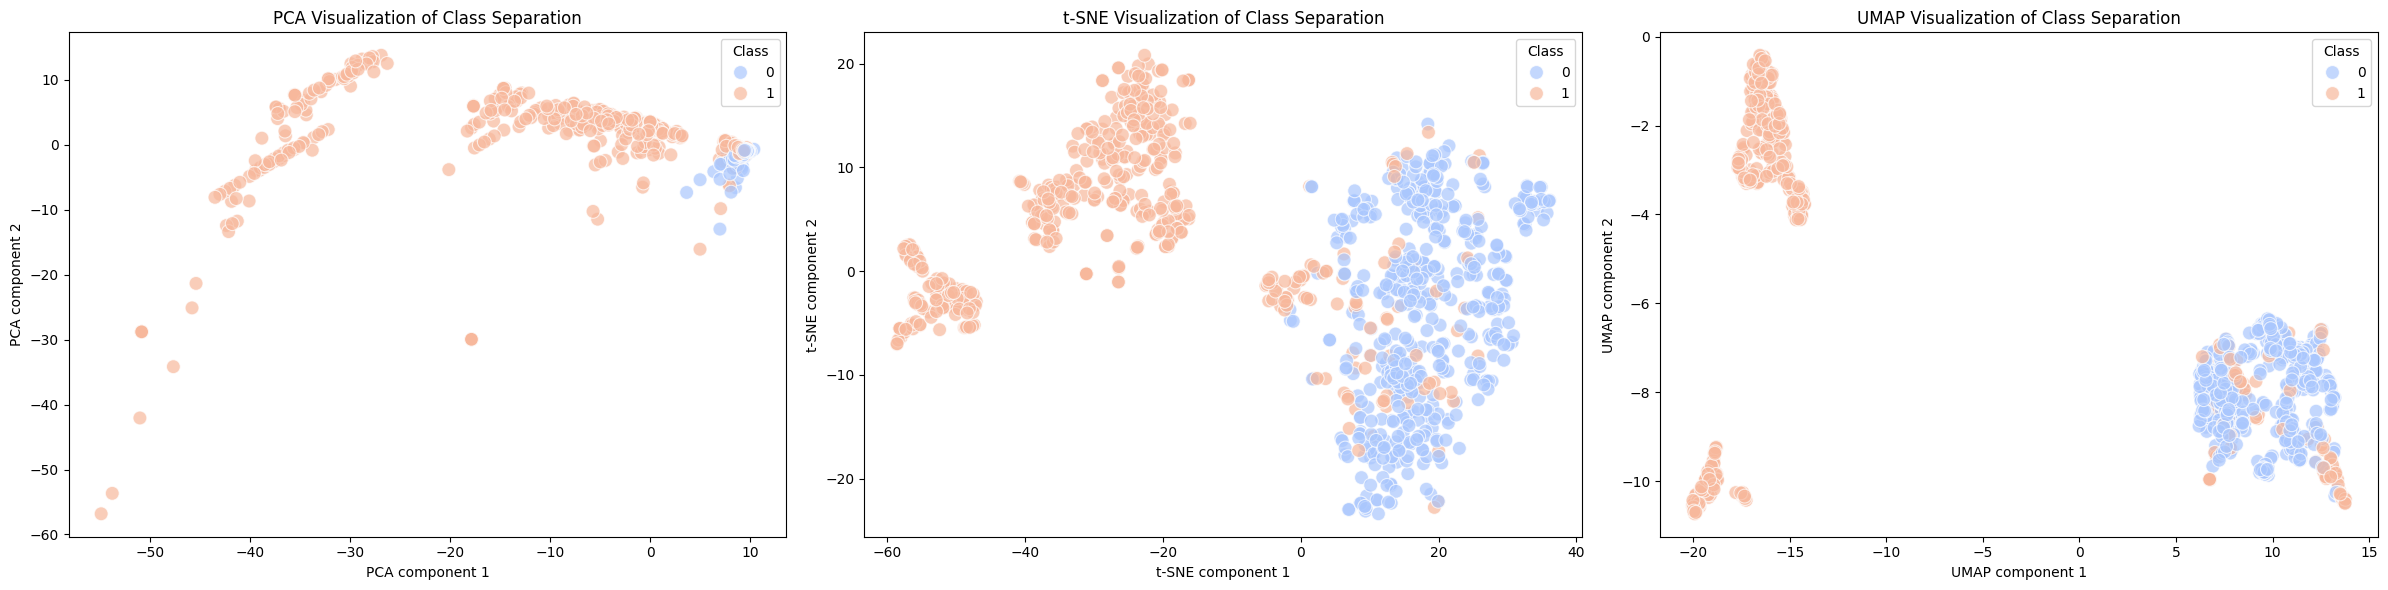

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(24, 6))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_weighted)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_weighted, palette='coolwarm', s=100, alpha=0.7, ax=ax[0]);
ax[0].set_title('PCA Visualization of Class Separation')
ax[0].set_xlabel('PCA component 1')
ax[0].set_ylabel('PCA component 2')


tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_weighted)

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_weighted, palette='coolwarm', s=100, alpha=0.7, ax=ax[1]);
ax[1].set_title('t-SNE Visualization of Class Separation')
ax[1].set_xlabel('t-SNE component 1')
ax[1].set_ylabel('t-SNE component 2')


model_umap = UMAP(n_components=2, random_state=42)
X_umap = model_umap.fit_transform(X_weighted)

sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_weighted, palette='coolwarm', s=100, alpha=0.7, ax=ax[2]);
ax[2].set_title('UMAP Visualization of Class Separation')
ax[2].set_xlabel('UMAP component 1')
ax[2].set_ylabel('UMAP component 2')


plt.tight_layout();
plt.show();

**PCA:** Классы (0 — нормальные транзакции, 1 — мошеннические) не разделяются явно в этом графике. Можно заметить, что классы сильно пересекаются, и нет четкого разделения. Это говорит о том, что PCA плохо разделяет классы, поскольку он сохраняет только глобальную структуру данных и не способен уловить сложные нелинейные зависимости между признаками.

**t-SNE:** Здесь видно, что классы начали разделяться. Однако, это не так явно, как хотелось бы. Точки мошеннических транзакций (класс 1) расположены близко друг к другу, но в значительной степени все равно есть перекрытие с нормальными транзакциями. Это также может указывать на похожесть признаков двух классов или на сложность данных, требующих более сложных моделей для разделения.

**UMAP:** Хорошо разделяет классы (класс 0 — нормальные и класс 1 — мошеннические транзакции). Мошеннические транзакции образуют отдельные кластеры, которые расположены на значительном расстоянии от нормальных транзакций. Это подтверждает, что UMAP гораздо лучше сохраняет глобальную структуру и выделяет кластерные особенности классов. 

In [30]:
X_umap

array([[ 10.334366 ,  -6.55005  ],
       [-17.53191  ,  -2.8185468],
       [ 10.881216 ,  -8.34453  ],
       ...,
       [ 12.052841 ,  -7.882124 ],
       [-16.461182 ,  -1.0466472],
       [-15.52212  ,  -1.7284663]], dtype=float32)

Добавим UMAP компоненты к данным, для того, чтобы модель лучше разделяла классы.

In [33]:
X = data.drop(columns=['Class'])
y = data['Class']

In [34]:
umap_components = model_umap.fit_transform(X)

X['umap_1'] = umap_components[:, 0]
X['umap_2'] = umap_components[:, 1]

c:\Users\46120\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### 4.3. Генерация синтетических данных

In [43]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
sm = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

Обучим логистическую регрессию.

In [51]:
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train_sm, y_train_sm)

pred = model_lr.predict(X_val)
pred_proba = model_lr.predict_proba(X_val)[:, 1]

print("Classification Report:\n", classification_report(y_val, pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



F1-score уменьшился с 0.12 до 0.11, при обучение логистической регресии с SMOTE, что говорит о: SMOTE не так эффективен, либо логическая регрессия не улавливает изменение в данных (зависимость в данных нелинейна). В отличие от логической регрессии, **XGBoost ловит сложные зависимости** между признаками, в том числе `umap_1`, `umap_2`.

In [54]:
model_xgb = xgb.XGBClassifier(scale_pos_weight=100, eval_metric='logloss', random_state=42)

In [58]:
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_val)

print("Classification Report without SMOTE:\n\n", classification_report(y_val, pred_xgb))


Classification Report without SMOTE:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [59]:
model_xgb.fit(X_train_sm, y_train_sm)

pred_xgb_smote = model_xgb.predict(X_val)

print("Classification Report with SMOTE:\n\n", classification_report(y_val, pred_xgb_smote))


Classification Report with SMOTE:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.85      0.71        98

    accuracy                           1.00     56962
   macro avg       0.81      0.92      0.85     56962
weighted avg       1.00      1.00      1.00     56962



Резкое увеличение F1-score c 0.12, до 0.88 без SMOTE и до 0.71 с SMOTE подтверждает теорию о нелинейности в данных. **Откажимся от SMOTE**, т.к. он немного "шумит" данные. В дальнейшем **будем использовать модели, которые могут уловить нелинейность в данных**. 

**Вывод**

UMAP помог вытащить сложные структуры → XGBoost их уловил. Поэтому теперь модель реально распознаёт мошенничество, а не угадывает случайно.

* Precision = 0.61. То есть 61 % всех предсказанных "Fraud" действительно мошенничества. Раньше было 6 % — это рост почти в 10 раз. Теперь модель не просто "подозревает всех", а делает обоснованные обвинения.
  
* Recall = 0.85. Это значит, что модель нашла 85 % всех реальных мошенничеств — и при этом не потеряла адекватность (precision всё ещё высокий).
  
* Accuracy = 1. В задаче с дисбалансом этот показатель не очень информативен.

* F1-score = 0.88. Говорит о хорошем балансе precision и recall. В baseline F1-score был 0.12, в итоге прирост составляет 0.76.

#### 4.4. Оценка важности признаков

In [71]:
importance = pd.DataFrame(model_xgb.feature_importances_, index=X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)

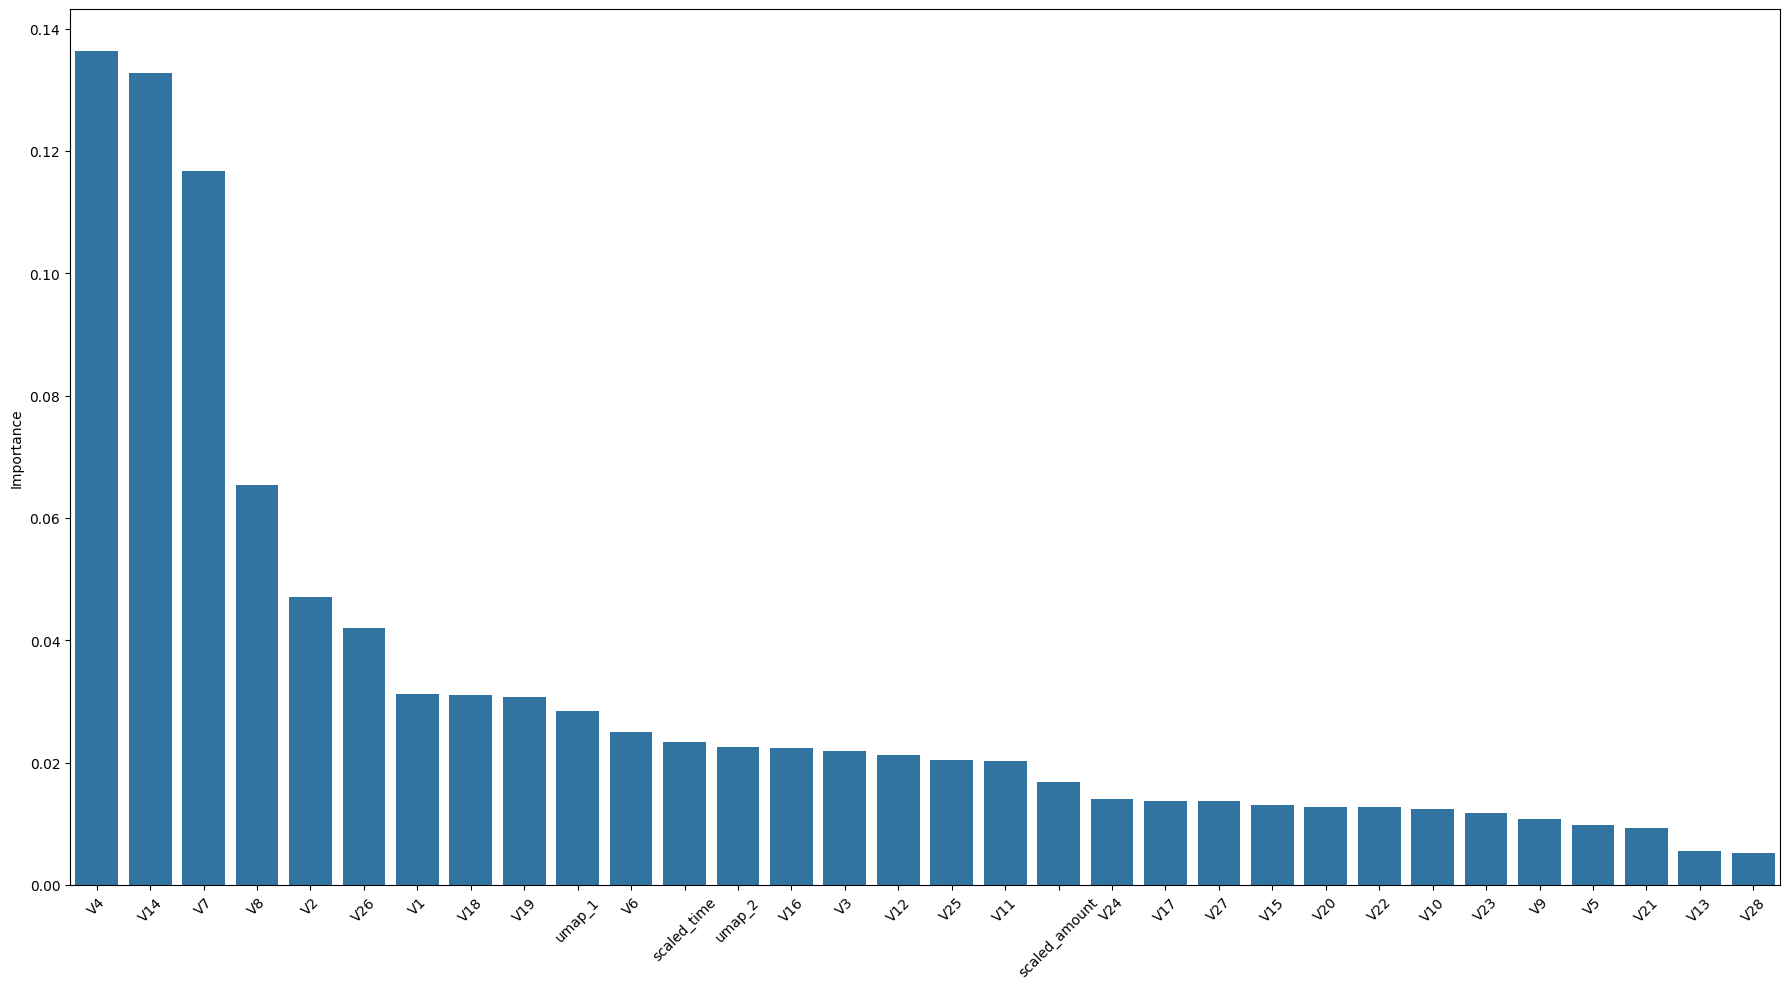

In [81]:
plt.figure(figsize=(18, 10))
sns.barplot(importance['Importance']);
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Мошеннические транзакции имеют специфические паттерны, которые лучше всего выражены в V4, V14 и V7. Так же `umap_1` = 0.028 и `umap_2` = 0.022 это хороший знак - **UMAP нашёл нелинейные шаблоны мошенничества**, которые не отражены в V1–V28 напрямую. Но при этом они не перепрыгнули важность PCA-фич и они лучше, чем часть оригинальных признаков (V13, V28, V21...). Отличный баланс UMAP не шум, а реальная полезная добавка. V13, V28, V21 < 0.01 эти признаки самые слабые.

In [82]:
X_train = X_train.drop(columns=['V21', 'V13', 'V28'])
X_val = X_val.drop(columns=['V21', 'V13', 'V28'])

In [88]:
model_xgb.fit(X_train, y_train)

pred = model_xgb.predict(X_val)

print("Classification Report:\n\n", classification_report(y_val, pred))

Classification Report:

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.98      0.81      0.88        98

    accuracy                           1.00     56962
   macro avg       0.99      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



Хоть и F1-score и не увеличился, но он и уменьшился что говорит о не нужности удаленных фичей.

#### 4.5. Сохранение результатов

In [96]:
X_data = pd.concat([X_train, X_val])
y_data = pd.concat([y_train, y_val])

data = X_data.join(y_data)

In [99]:
data.to_csv('./data/pred_data.csv')